In [1]:
import numpy as np
import os
import cv2
from sklearn.utils import shuffle
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import gc
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D, Activation
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as preprocess_mobilenetv2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import BatchNormalization
import kagglehub
import seaborn as sns
import pandas as pd
import skimage
from skimage.transform import resize
from sklearn.metrics import classification_report, confusion_matrix
import os
from glob import glob
import random
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.layers import Input, Layer, MultiHeadAttention, LayerNormalization, Dense
from tensorflow.keras.layers import Add, Embedding, Reshape
from tensorflow.keras.initializers import glorot_uniform
import math

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

2025-06-19 23:51:16.649399: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750377076.847977      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750377076.903507      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
import kagglehub
grassknoted_asl_alphabet_path = kagglehub.dataset_download('grassknoted/asl-alphabet')

train_path = os.path.join(grassknoted_asl_alphabet_path, '/kaggle/input/asl-alphabet/asl_alphabet_train/asl_alphabet_train')
print('Data source import complete.')

Data source import complete.


In [3]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
tf.config.list_physical_devices()

tf.test.is_gpu_available()

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
            print("GPU configured successfully")
    except RuntimeError as e:
        print("Error configuring GPU:", e)

Num GPUs Available:  1
GPU configured successfully


I0000 00:00:1750377089.547919      35 gpu_device.cc:2022] Created device /device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [4]:
target_size = (96, 96)
target_dims = (96, 96, 3)
n_classes = 29
val_frac = 0.1
batch_size = 256

data_augmentor = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=False,
    rescale=1./255,
    validation_split=val_frac
)

In [5]:
train_gen = data_augmentor.flow_from_directory(train_path, target_size=target_size, batch_size=batch_size, shuffle=True, subset='training')
val_gen = data_augmentor.flow_from_directory(train_path, target_size=target_size, batch_size=batch_size, subset='validation')

Found 78300 images belonging to 29 classes.
Found 8700 images belonging to 29 classes.


In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models, initializers

class PatchEmbedding(layers.Layer):
    def __init__(self, patch_size, projection_dim):
        super().__init__()
        self.patch_size = patch_size
        self.projection_dim = projection_dim
        self.projection = layers.Conv2D(
            filters=projection_dim,
            kernel_size=patch_size,
            strides=patch_size,
            padding='valid'
        )

    def call(self, images):
        # Shape: (batch_size, height/patch, width/patch, projection_dim)
        patches = self.projection(images)
        # Flatten to (batch_size, num_patches, projection_dim)
        patch_dims = tf.shape(patches)[1] * tf.shape(patches)[2]
        return tf.reshape(patches, (tf.shape(images)[0], patch_dims, self.projection_dim))


In [7]:

class AddPositionEmbedding(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.position_embedding = self.add_weight(
            name="pos_embed", shape=(1, num_patches + 1, projection_dim),
            initializer=initializers.RandomNormal(stddev=0.06)
        )
        self.class_token = self.add_weight(
            name="cls_token", shape=(1, 1, projection_dim),
            initializer=initializers.Zeros()
        )

    def call(self, x):
        batch_size = tf.shape(x)[0]
        class_token = tf.broadcast_to(self.class_token, [batch_size, 1, tf.shape(x)[-1]])
        x = tf.concat([class_token, x], axis=1)
        return x + self.position_embedding


In [8]:
def transformer_encoder(x, num_heads, ff_dim, dropout_rate):
    # Layer normalization and multi-head attention
    attn_input = layers.LayerNormalization(epsilon=1e-6)(x)
    attention_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=ff_dim)(attn_input, attn_input)
    attention_output = layers.Dropout(dropout_rate)(attention_output)
    out1 = layers.Add()([x, attention_output])

    # Layer normalization and MLP
    ffn_input = layers.LayerNormalization(epsilon=1e-6)(out1)
    ffn_output = layers.Dense(ff_dim * 2, activation='gelu')(ffn_input)
    ffn_output = layers.Dense(ff_dim)(ffn_output)
    ffn_output = layers.Dropout(dropout_rate)(ffn_output)
    return layers.Add()([out1, ffn_output])


In [9]:
def build_vit_model(
    input_shape=(96, 96, 3),
    patch_size=(16, 16),
    num_layers=6,
    projection_dim=64,
    num_heads=4,
    ff_dropout=0.1,
    num_classes=29
):
    inputs = layers.Input(shape=input_shape)

    # Compute number of patches
    num_patches = (input_shape[0] // patch_size[0]) * (input_shape[1] // patch_size[1])

    # Patch embedding
    x = PatchEmbedding(patch_size, projection_dim)(inputs)
    x = AddPositionEmbedding(num_patches, projection_dim)(x)

    # Transformer layers
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, projection_dim, ff_dropout)

    # Classification head using class token (first token)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    class_token = x[:, 0]  # Extract class token
    x = layers.Dropout(ff_dropout)(class_token)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs, outputs)

In [10]:
vit_model = build_vit_model()

vit_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)
vit_model.summary()

I0000 00:00:1750377122.587535      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 96, 96, 3)      │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ patch_embedding           │ (None, 36, 64)         │         49,216 │ input_layer[0][0]      │
│ (PatchEmbedding)          │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_position_embedding    │ (None, 37, 64)         │          2,432 │ patch_embedding[0][0]  │
│ (AddPositionEmbedding)    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization       │ (None, 37, 64)         │            128 │ add_position_embeddin… │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multi_head_attention      │ (None, 37, 64)         │         66,368 │ layer_normalization[0… │
│ (MultiHeadAttention)      │                        │                │ layer_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_1 (Dropout)       │ (None, 37, 64)         │              0 │ multi_head_attention[… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 37, 64)         │              0 │ add_position_embeddin… │
│                           │                        │                │ dropout_1[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_1     │ (None, 37, 64)         │            128 │ add[0][0]              │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 37, 128)        │          8,320 │ layer_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 37, 64)         │          8,256 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_2 (Dropout)       │ (None, 37, 64)         │              0 │ dense_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_1 (Add)               │ (None, 37, 64)         │              0 │ add[0][0],             │
│                           │                        │                │ dropout_2[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_2     │ (None, 37, 64)         │            128 │ add_1[0][0]            │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multi_head_attention_1    │ (None, 37, 64)         │         66,368 │ layer_normalization_2… │
│ (MultiHeadAttention)      │                        │                │ layer_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_4 (Dropout)       │ (None, 37, 64)         │              0 │ multi_head_attention_… │
├──────────────────────

 Total params: 552,861 (2.11 MB)

 Trainable params: 552,861 (2.11 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = vit_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

Epoch 1/10
306/306 ━━━━━━━━━━━━━━━━━━━━ 271s 886ms/step - accuracy: 0.2913 - loss: 2.2468 - val_accuracy: 0.3969 - val_loss: 1.7957
Epoch 2/10
306/306 ━━━━━━━━━━━━━━━━━━━━ 262s 858ms/step - accuracy: 0.5371 - loss: 1.3895 - val_accuracy: 0.5162 - val_loss: 1.4989
Epoch 3/10
306/306 ━━━━━━━━━━━━━━━━━━━━ 278s 910ms/step - accuracy: 0.6628 - loss: 0.9883 - val_accuracy: 0.5775 - val_loss: 1.3400
Epoch 4/10
306/306 ━━━━━━━━━━━━━━━━━━━━ 272s 891ms/step - accuracy: 0.7446 - loss: 0.7426 - val_accuracy: 0.6037 - val_loss: 1.2332
Epoch 5/10
306/306 ━━━━━━━━━━━━━━━━━━━━ 277s 906ms/step - accuracy: 0.7904 - loss: 0.6019 - val_accuracy: 0.7003 - val_loss: 0.9554
Epoch 6/10
306/306 ━━━━━━━━━━━━━━━━━━━━ 272s 889ms/step - accuracy: 0.8385 - loss: 0.4624 - val_accuracy: 0.6924 - val_loss: 1.0002
Epoch 7/10
306/306 ━━━━━━━━━━━━━━━━━━━━ 275s 900ms/step - accuracy: 0.8563 - loss: 0.4119 - val_accuracy: 0.7368 - val_loss: 0.8381
Epoch 8/10
306/306 ━━━━━━━━━━━━━━━━━━━━ 278s 908ms/step - accuracy: 0.8817 -

34/34 ━━━━━━━━━━━━━━━━━━━━ 29s 835ms/step - accuracy: 0.7639 - loss: 0.7670
Validation Loss: 0.795403242111206
Validation Accuracy: 0.7612643837928772


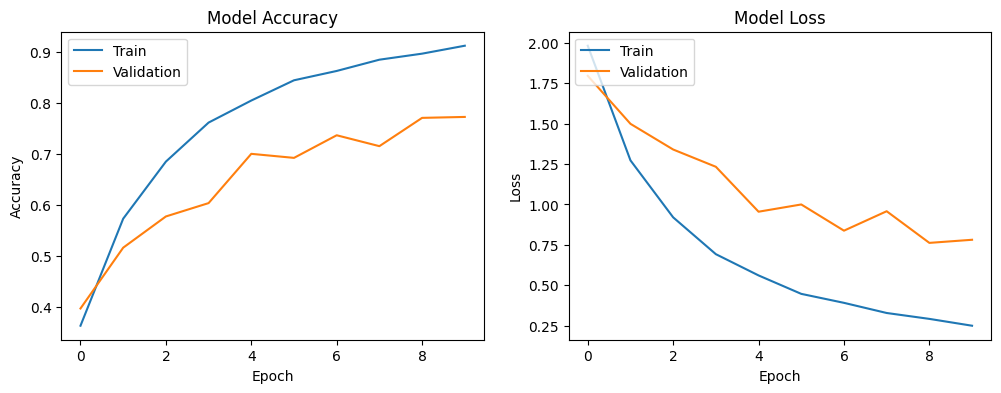

In [13]:
val_loss, val_accuracy = vit_model.evaluate(val_gen)
print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_accuracy}")

def plot_training_history(history):
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    
    plt.show()

plot_training_history(history)

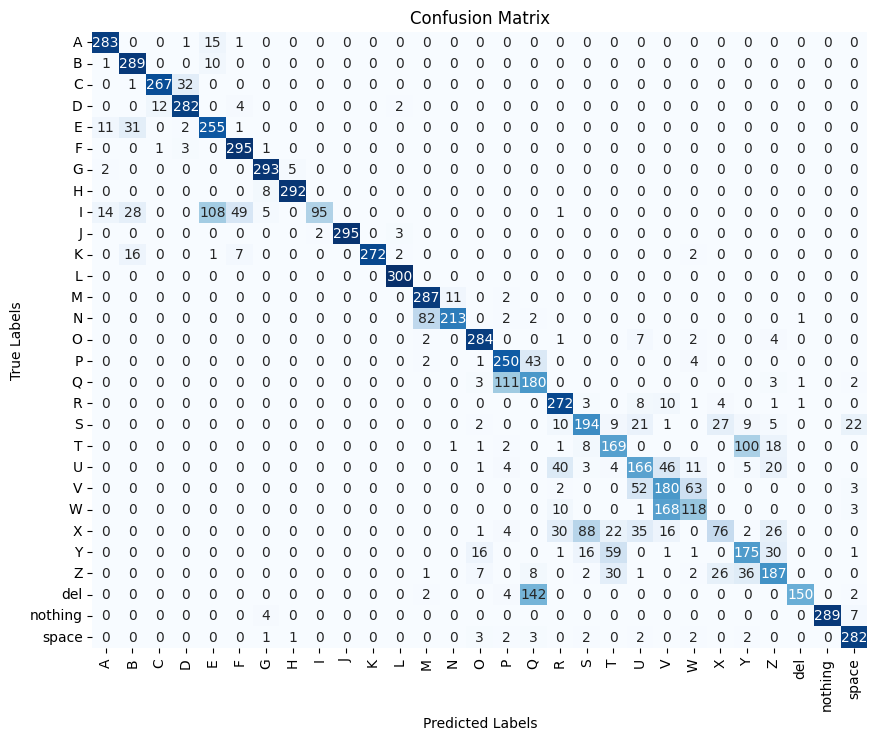

In [15]:
def get_true_and_pred_labels(generator, model):
    true_labels = []
    pred_labels = []

    for _ in range(len(generator)):
        X, y = next(generator)
        true_labels.extend(np.argmax(y, axis=1))
        preds = model.predict(X, verbose=0)
        pred_labels.extend(np.argmax(preds, axis=1))
    
    return true_labels, pred_labels

true_labels, pred_labels = get_true_and_pred_labels(val_gen, vit_model)

cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=train_gen.class_indices.keys(),
            yticklabels=train_gen.class_indices.keys())
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

Misclassified Examples:


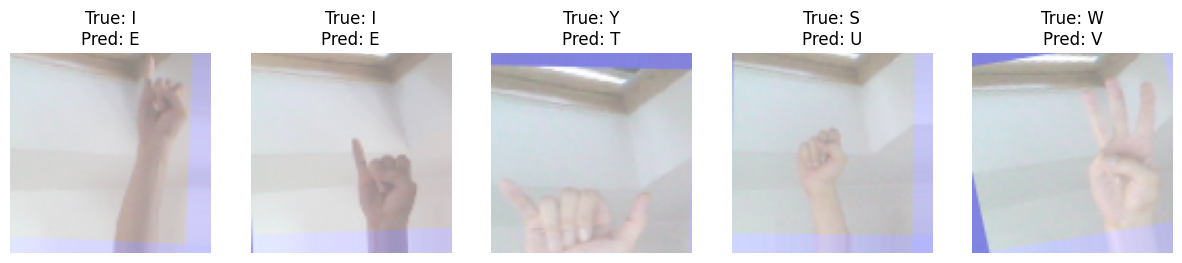

Correctly Classified Examples:


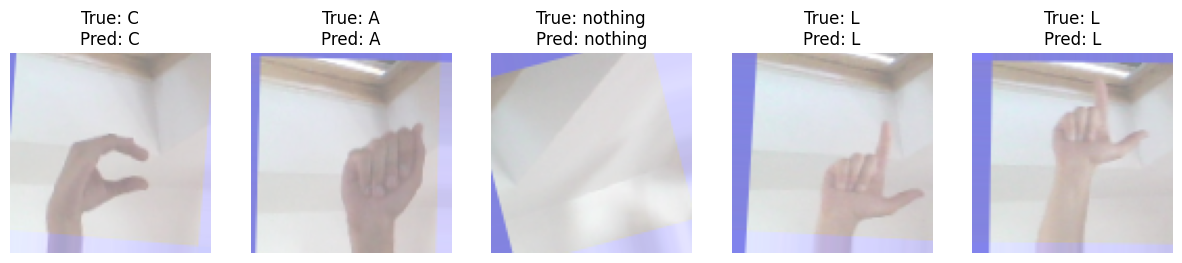

In [16]:
def display_examples(true_labels, pred_labels, generator, num_examples=5):
    class_names = list(generator.class_indices.keys())
    
    misclassified_indices = [i for i, (true, pred) in enumerate(zip(true_labels, pred_labels)) if true != pred]
    correct_indices = [i for i, (true, pred) in enumerate(zip(true_labels, pred_labels)) if true == pred]
    
    misclassified_samples = random.sample(misclassified_indices, min(num_examples, len(misclassified_indices)))
    correct_samples = random.sample(correct_indices, min(num_examples, len(correct_indices)))
    
    print("Misclassified Examples:")
    plt.figure(figsize=(15, 5))
    for i, idx in enumerate(misclassified_samples):
        X, y = generator[idx // generator.batch_size]
        img = X[idx % generator.batch_size]
        true_label = class_names[true_labels[idx]]
        pred_label = class_names[pred_labels[idx]]
        
        plt.subplot(1, num_examples, i + 1)
        plt.imshow((img + 1) / 2) 
        plt.title(f"True: {true_label}\nPred: {pred_label}")
        plt.axis('off')
    plt.show()
    
    print("Correctly Classified Examples:")
    plt.figure(figsize=(15, 5))
    for i, idx in enumerate(correct_samples):
        X, y = generator[idx // generator.batch_size]
        img = X[idx % generator.batch_size]
        true_label = class_names[true_labels[idx]]
        pred_label = class_names[pred_labels[idx]]
        
        plt.subplot(1, num_examples, i + 1)
        plt.imshow((img + 1) / 2) 
        plt.title(f"True: {true_label}\nPred: {pred_label}")
        plt.axis('off')
    plt.show()

display_examples(true_labels, pred_labels, val_gen, num_examples=5)